# Demo data generation 1 for 1

In this notebook, there is a simple example of how to generate a list of measures for different states of the engine with different contexts for each of them (1 context for 1 state).
You will also find in this notebook some visualisations of the different variables.

In [1]:
%matplotlib inline
%load_ext autoreload
%autoreload 2

In [2]:
# Standard imports
import numpy as np
import matplotlib.pyplot as plt
import time

# Specific imports
from odsmr.sensors import HPC_Tout, HP_Nmech, HPC_Tin, LPT_Tin, Fuel_flow, HPC_Pout_st, LP_Nmech
from odsmr.context import  FlightCondDeckSMR, ContextDeckSMR
from odsmr.generation_functions import decksmr_1for1
from odsmr.helpers import sample_from_bounds, dict_to_array, extract_info
from odsmr.constants import FLIGHT_CONDITIONS_BOUNDS, STATE_BOUNDS, ROOT_OPENDECK, STATE_LABELS, FlightPhaseType


In [3]:
# Define list of desired sensors, which will be the same for all the experiments
list_sensors = [HPC_Tout(),
     HP_Nmech(),
     HPC_Tin(),
     LPT_Tin(),
     Fuel_flow(),
     HPC_Pout_st(),
     LP_Nmech()]

## Example 1: one random health state, for a random flight condition

In [4]:
# Here, we generate one random point at a random condition:
phase_type = FlightPhaseType.CRUISE.value
list_states = [dict_to_array(sample_from_bounds(STATE_BOUNDS))]
flight_conditions = sample_from_bounds(FLIGHT_CONDITIONS_BOUNDS[phase_type])
list_contexts = [ContextDeckSMR(
                    name="OneSampled_"+phase_type+"_DECKSMR",
                    flight_condition=FlightCondDeckSMR(
                        DTAMB=flight_conditions["DTAMB"],
                        ALT=flight_conditions["ALT"], 
                        MACH=flight_conditions["MACH"],  
                        COMMAND=flight_conditions["COMMAND"],
                        PHASE_TYPE=phase_type
                    )
                )]
all_info_df = decksmr_1for1(list_state_value= list_states, list_context=list_contexts, list_sensors=list_sensors, sim_root=ROOT_OPENDECK)
all_info_df.head()

,HPC_Tout,HP_Nmech,HPC_Tin,LPT_Tin,Fuel_flow,HPC_Pout_st,LP_Nmech,Convergence,deg_CmpBst_s_mapEff_in,deg_CmpBst_s_mapWc_in,...,deg_TrbH_s_mapEff_in,deg_TrbH_s_mapWc_in,deg_TrbL_s_mapEff_in,deg_TrbL_s_mapWc_in,context_name,phase_type,DTAMB,ALT,COMMAND,MACH
0,821.305506,19750.2985,338.019163,1196.20387,0.401738,1397611.38,3987.0921,Calculation convergence: OK,-0.02534,-0.028678,...,-0.025567,-0.007154,-0.016241,0.019505,OneSampled_CR_DECKSMR,CR,9.465803,34999.863995,24996.466649,0.789512


## Example 2: several random health states, for the same number of random flight conditions

In [5]:
# Generate measurements points: here, we define different contexts in the bounds of flight conditions
data_max_size = 250
all_result = {}
for ids, phase_type in enumerate(
            [
                FlightPhaseType.CRUISE.value,
                FlightPhaseType.TAKEOFF.value,
                FlightPhaseType.CLIMB.value
            ]
        ):
            print("Simulations in Phase:", phase_type)

            list_states_values = [dict_to_array(sample_from_bounds(STATE_BOUNDS)) for ids in range(data_max_size)]
            flight_conditions = [sample_from_bounds(FLIGHT_CONDITIONS_BOUNDS[phase_type]) for ids in range(data_max_size)]
            list_contexts = [ContextDeckSMR(
                    name="Sampled_"+phase_type+"_DECKSMR",
                    flight_condition=FlightCondDeckSMR(
                        DTAMB=fc["DTAMB"],
                        ALT=fc["ALT"], 
                        MACH=fc["MACH"],  
                        COMMAND=fc["COMMAND"],
                        PHASE_TYPE=phase_type
                    )
                )
                for fc in flight_conditions]

            print('number of tested points:', len(list_states_values), " states for ", len(list_contexts), " contexts")
            t1 = time.time()
            result = decksmr_1for1(list_state_value= list_states_values, list_context=list_contexts, list_sensors=list_sensors, sim_root=ROOT_OPENDECK)
            t2 = time.time()
            print('time:', t2-t1, "s")
            all_result[phase_type] = result

Simulations in Phase: CR
number of tested points: 250  states for  250  contexts
time: 30.665615797042847 s
Simulations in Phase: MTO
number of tested points: 250  states for  250  contexts
time: 46.640535831451416 s
Simulations in Phase: MCL
number of tested points: 250  states for  250  contexts
time: 48.51627802848816 s


## Visualizations

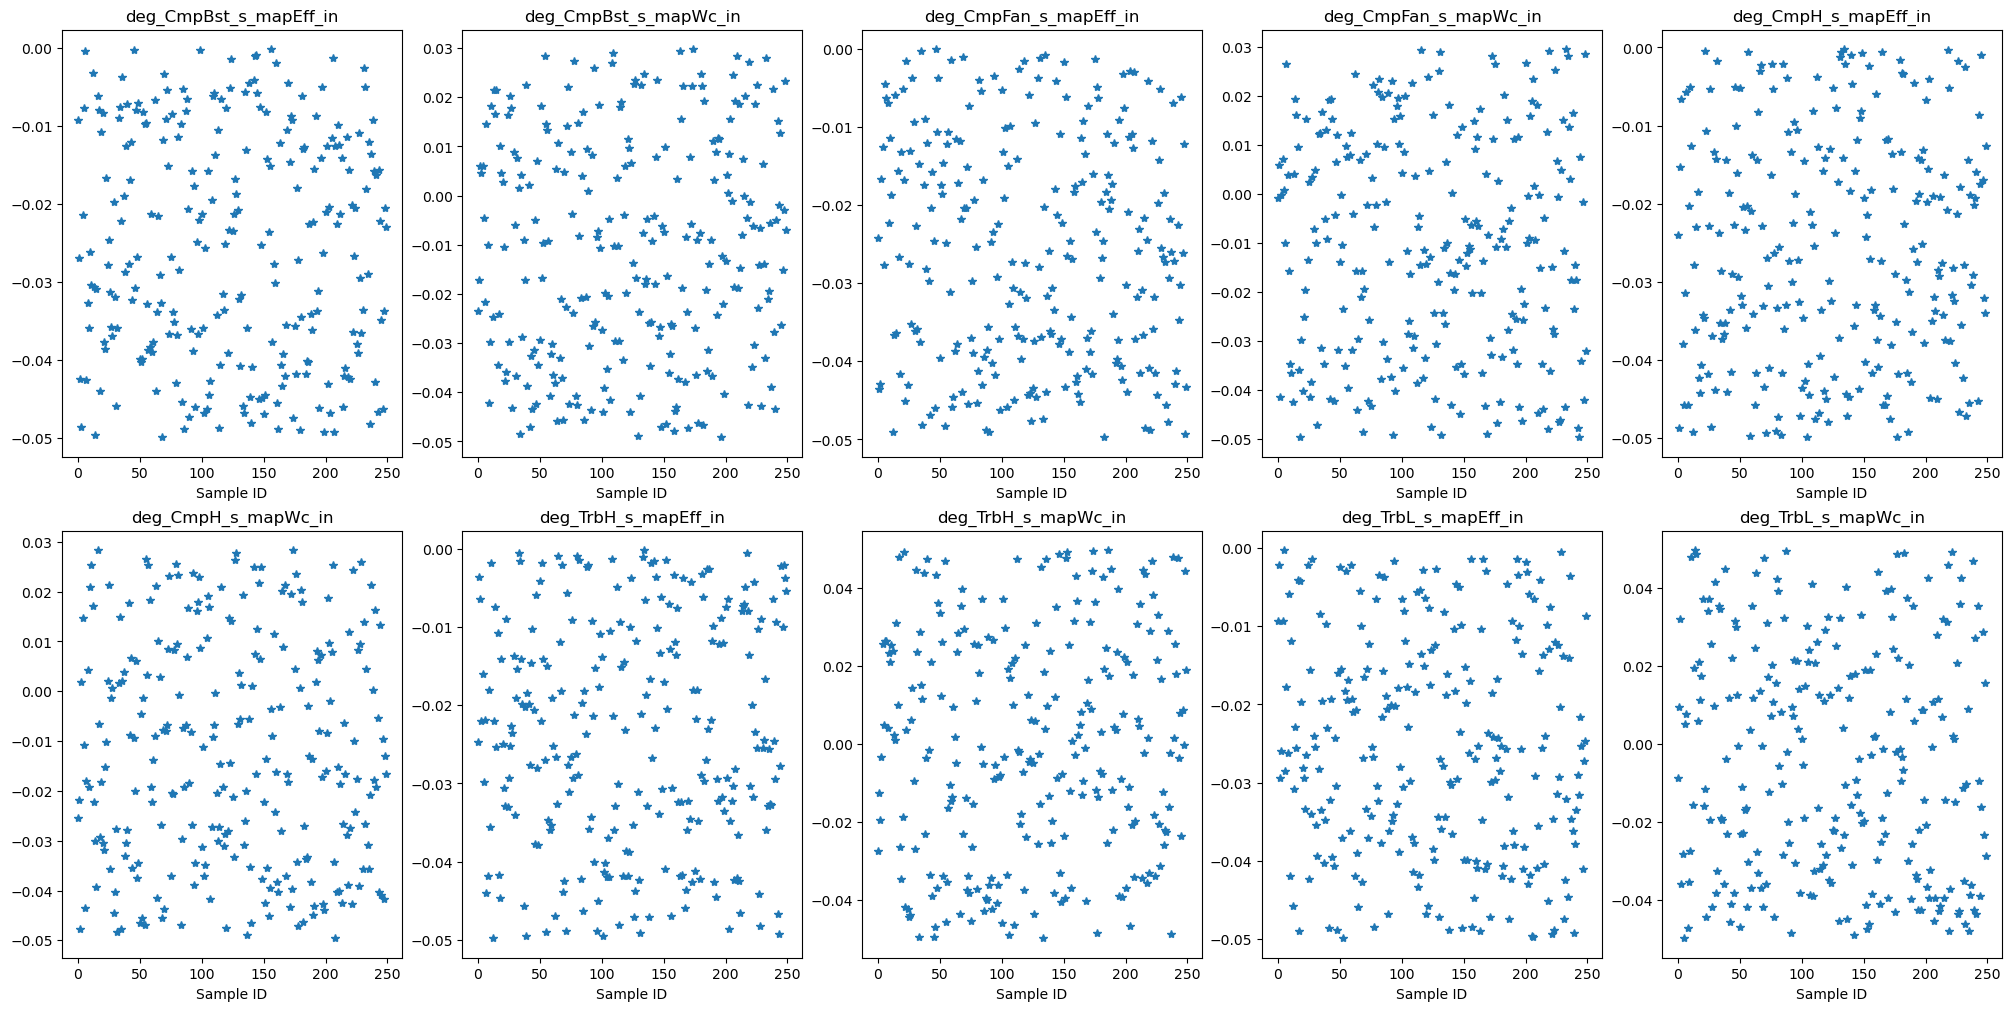

In [6]:
# Samples of health states within the bounds
plt.figure(figsize=(20, 10), layout="constrained")
id_plot = 1
id_plot = 1
for id_state in range(10):
     plt.subplot(2, 5, id_plot)
     id_plot += 1
     plt.plot(np.array(list_states_values)[:, id_state], "*")
     plt.title(STATE_LABELS[id_state])
     plt.xlabel('Sample ID')


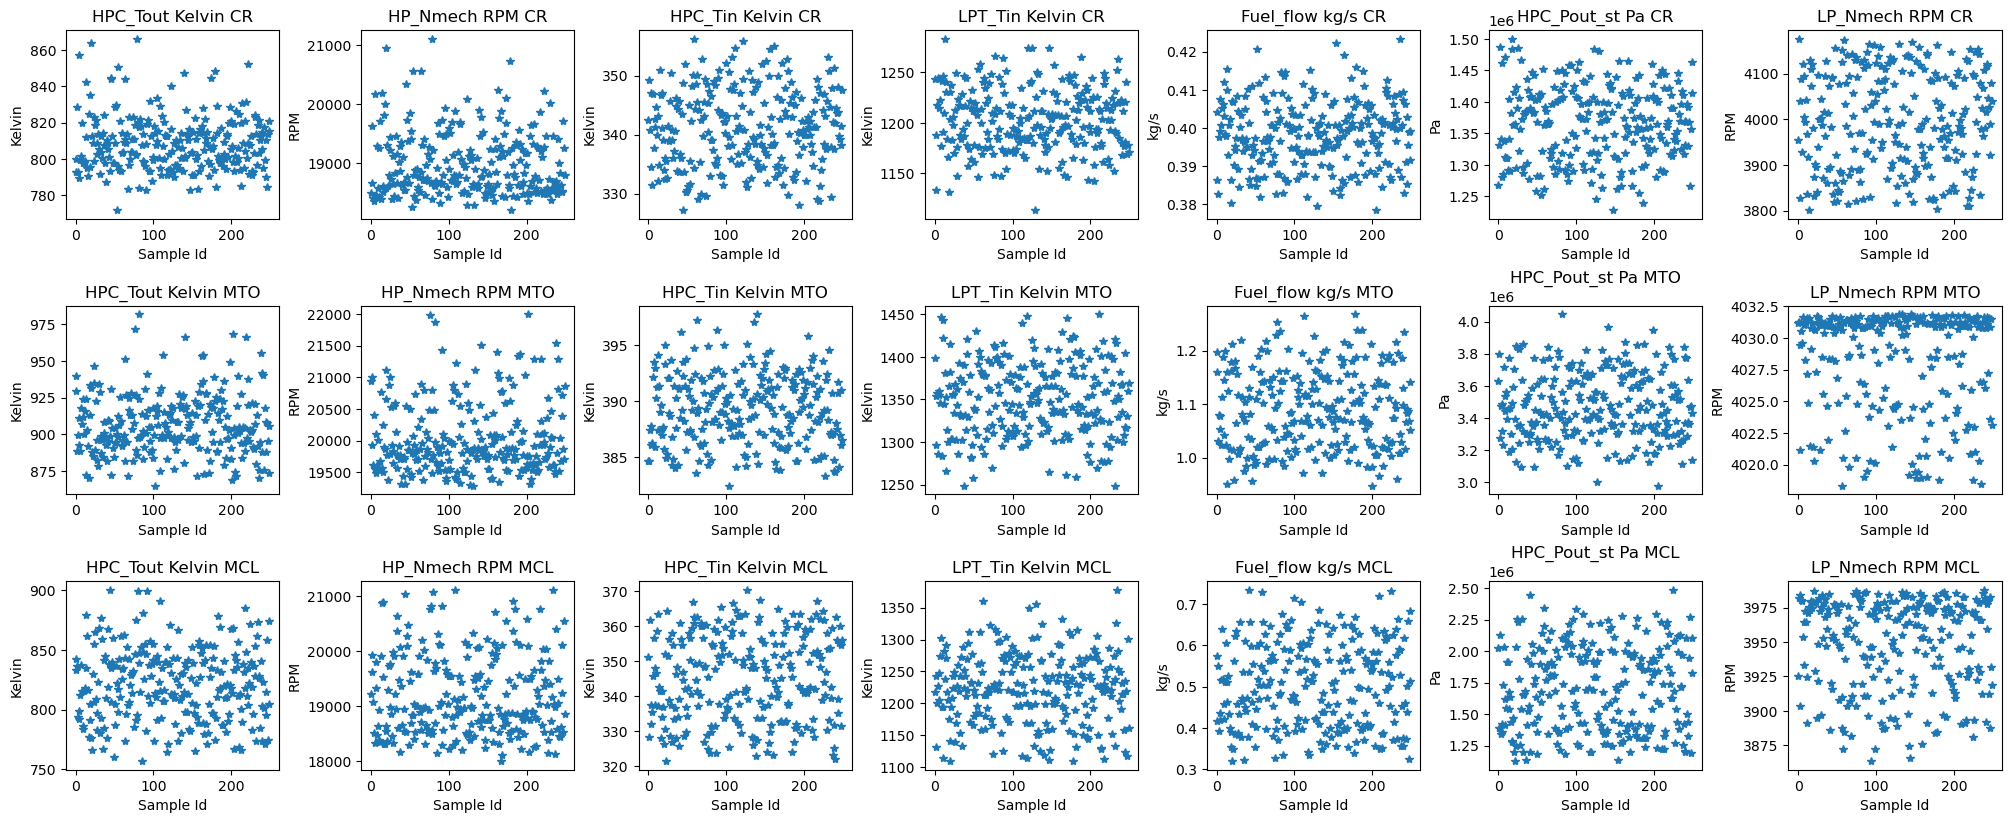

In [7]:
# Sensors values obtained from random health states
plt.figure(figsize=(20, 10), layout="constrained")
id_plot = 1
for ids, phase_type in enumerate(
            [
                FlightPhaseType.CRUISE.value,
                FlightPhaseType.TAKEOFF.value,
                FlightPhaseType.CLIMB.value,
            ]
        ):
    # We can extract specifically the measurements
    measurements = extract_info(all_result[phase_type], list_variables_name=[s.name for s in list_sensors]+['Convergence'], context_name=True, phase_type=False, flight_conditions=False)

    for id_sensor, sensor in enumerate(list_sensors):
        if id_sensor < len(list_sensors):
            plt.subplot(4, len(list_sensors), id_plot)
            id_plot += 1
            plt.plot(all_result[phase_type][sensor.name], '*')
            plt.title(sensor.name + " "+sensor.unit + " " + phase_type)
            plt.ylabel(sensor.unit)
            plt.xlabel('Sample Id')

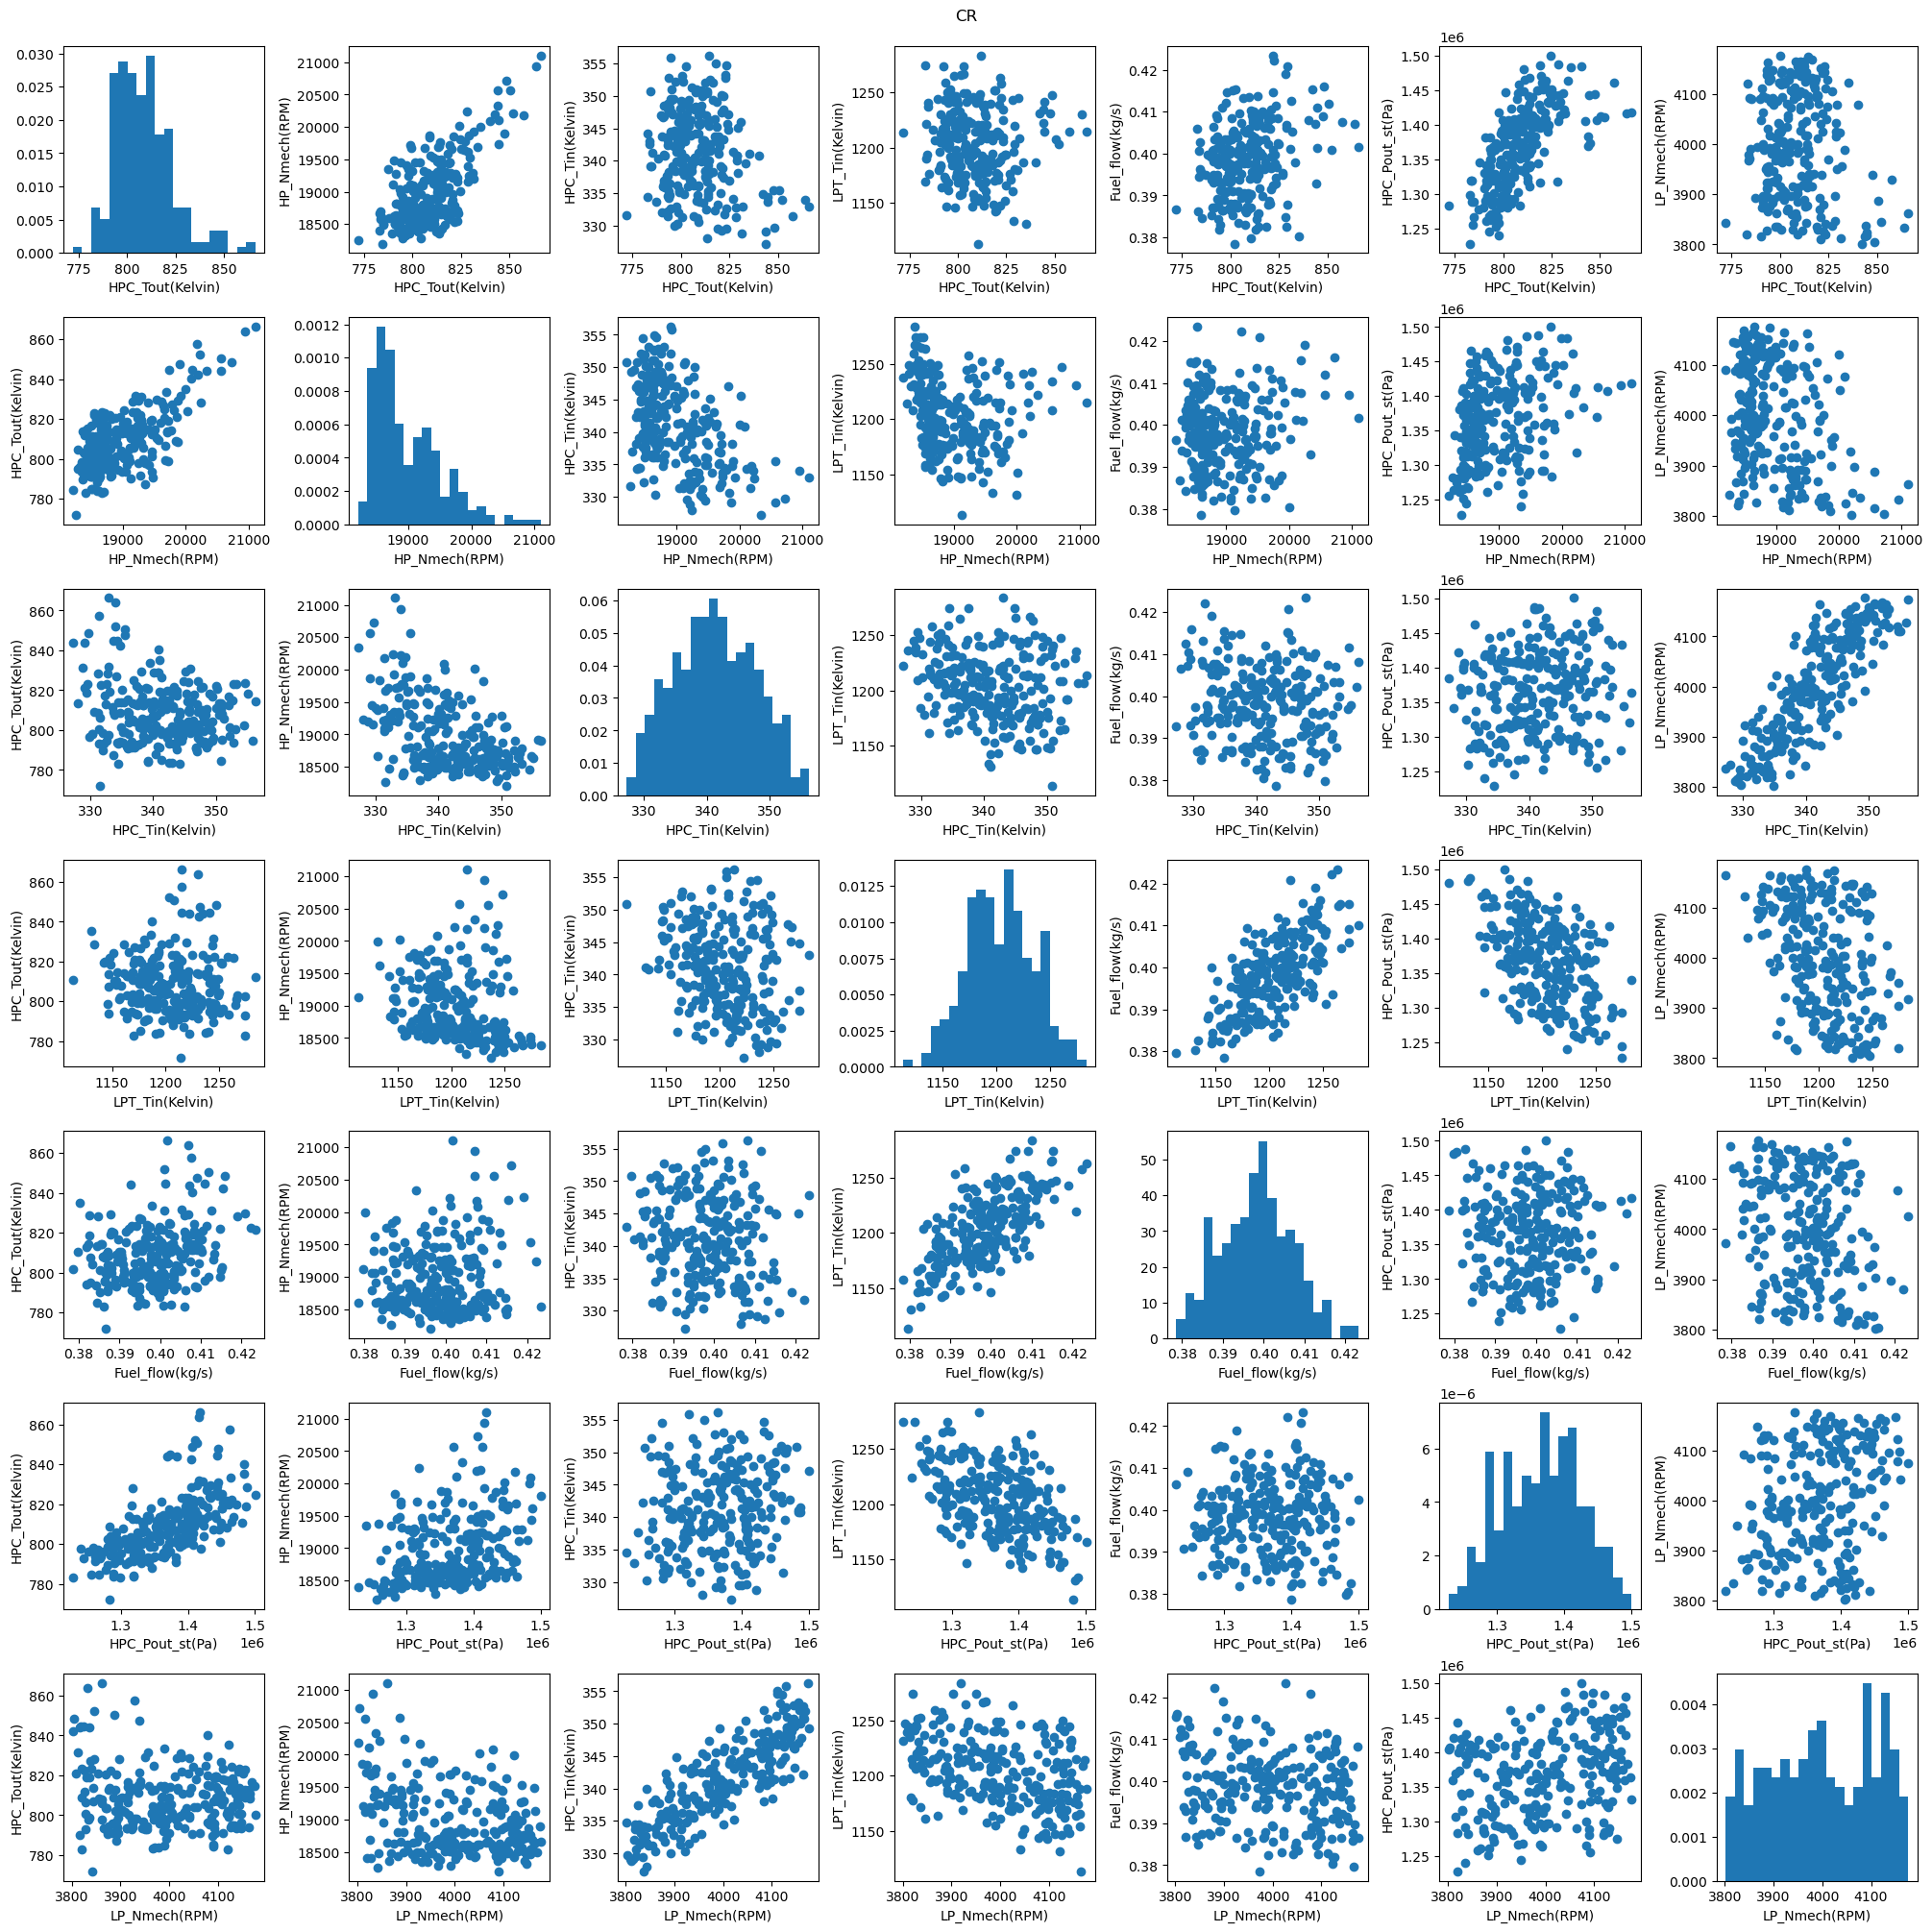

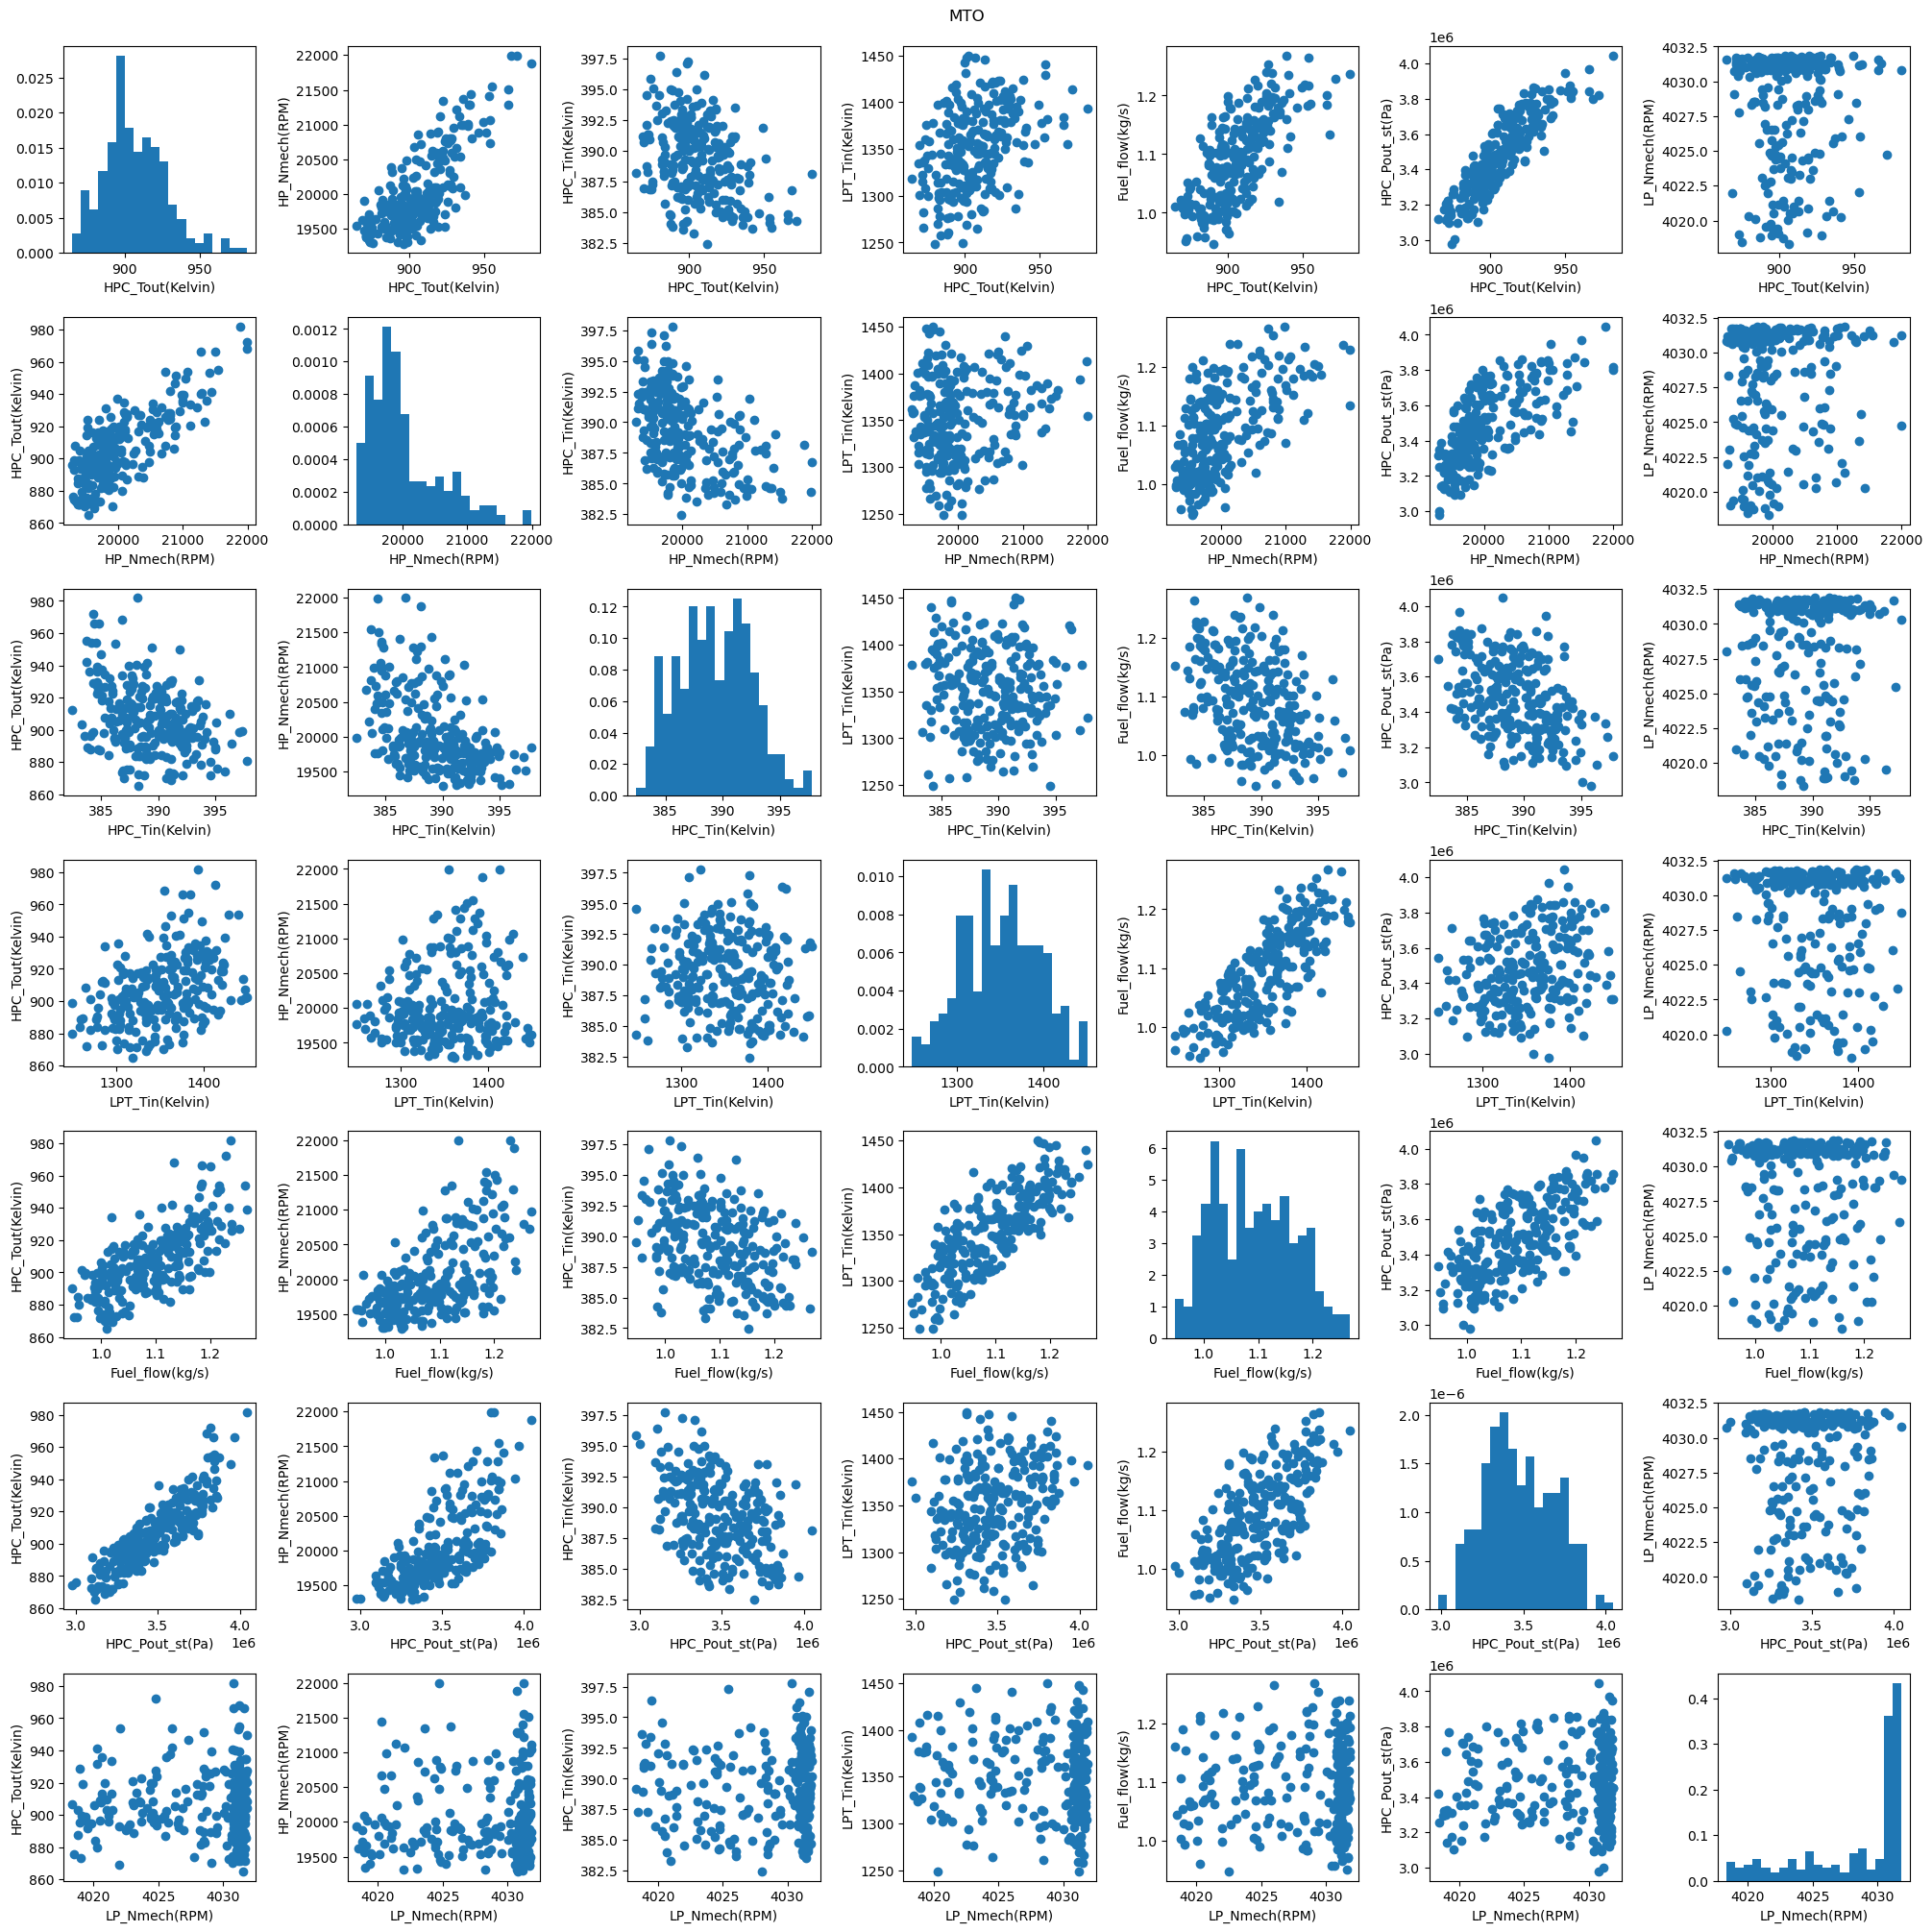

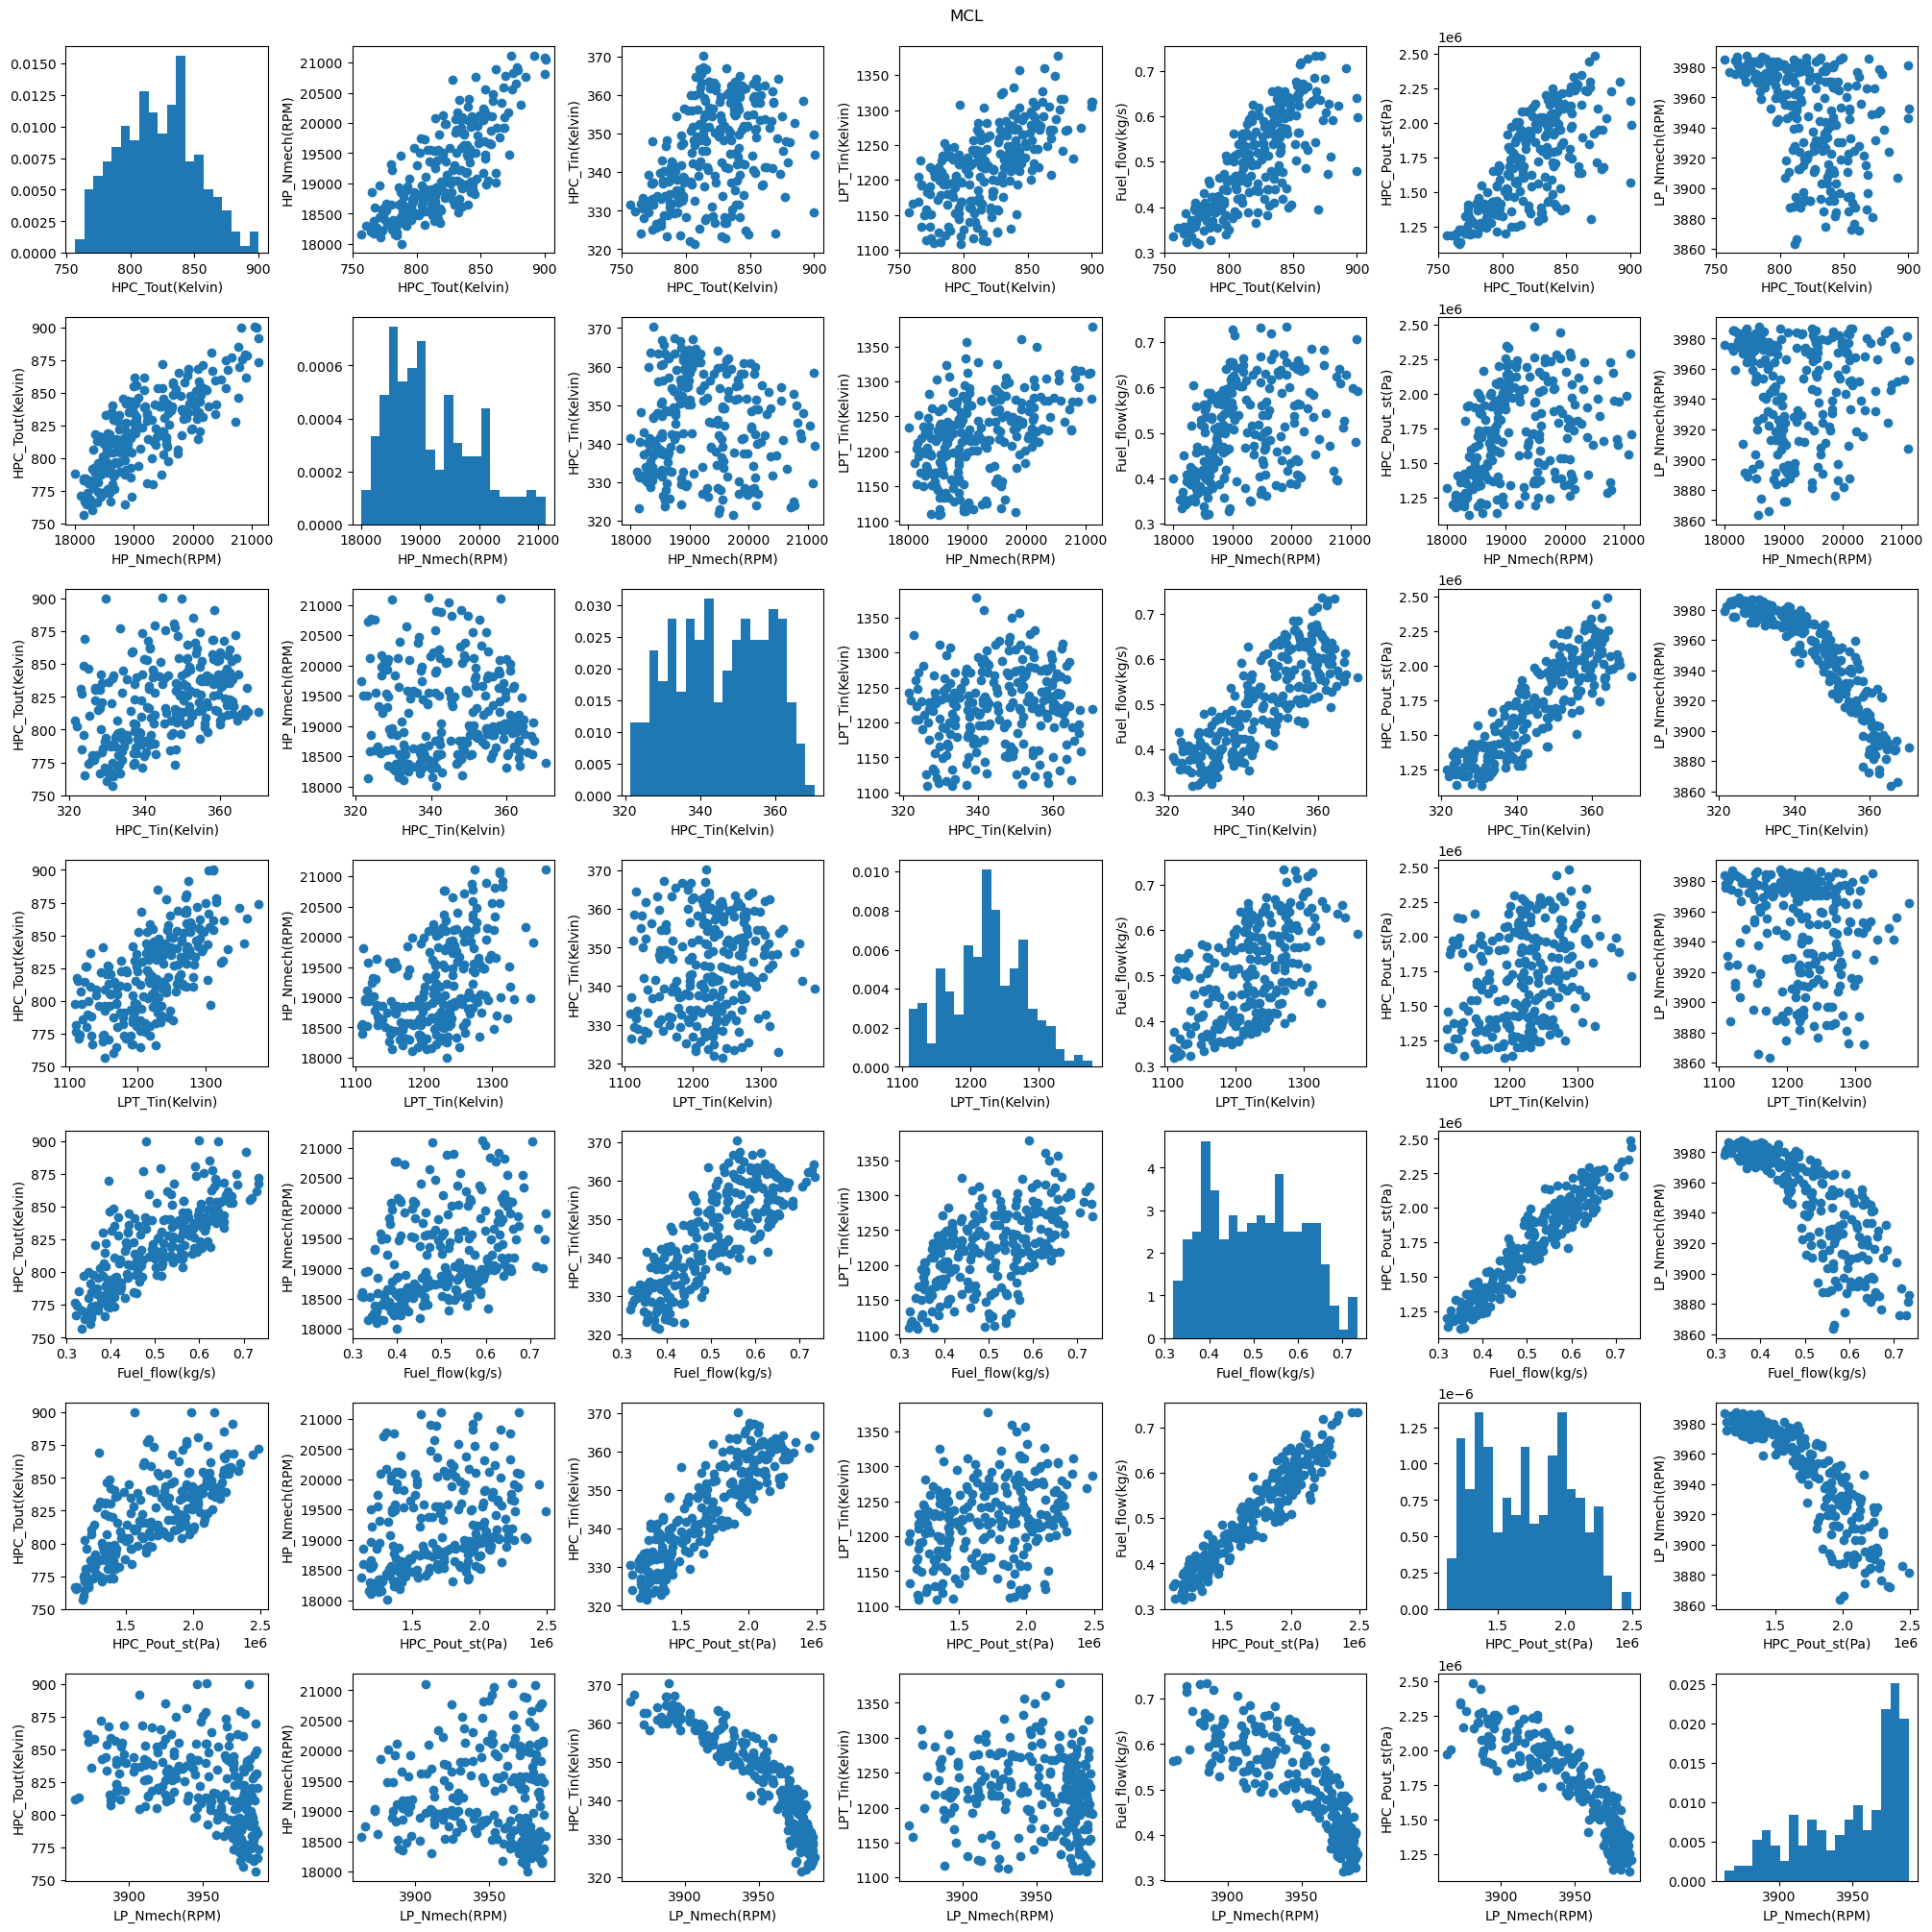

In [8]:
# Illustration of the pair relations between the sensors
for ids, phase_type in enumerate(
            [
                FlightPhaseType.CRUISE.value,
                FlightPhaseType.TAKEOFF.value,
                FlightPhaseType.CLIMB.value
            ]
        ):
    plt.figure(figsize=(20, 20), layout="constrained")
    id_plot = 1
    measurements = extract_info(all_result[phase_type], list_variables_name=[s.name for s in list_sensors], context_name=True, phase_type=False, flight_conditions=False)
    measurements.head()
    for id_sensor1, sensor1 in enumerate(list_sensors):
        if id_sensor1 < len(list_sensors):
            for id_sensor2, sensor2 in enumerate(list_sensors):
                if (id_sensor2 < len(list_sensors)): 
                    plt.subplot(len(list_sensors), len(list_sensors), id_plot)
                    if (id_sensor2 != id_sensor1):
                        plt.scatter(measurements[sensor1.name], all_result[phase_type][sensor2.name])
                        plt.xlabel(sensor1.name + "("+sensor1.unit+")")
                        plt.ylabel(sensor2.name+ "("+sensor2.unit+")")
                    if (id_sensor2 == id_sensor1):
                        plt.hist(measurements[sensor1.name], bins=20, density=True)
                        plt.xlabel(sensor1.name + "("+sensor1.unit+")")

                    id_plot += 1
    plt.suptitle(phase_type)
    
